# Extracting random samples from xarray.DataArray <img align="right" src="../Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with both the `NCI` and `DEA Sandbox` environments
* **Products used:** 
[ga_ls_landcover_class_cyear_3](https://explorer.dea.ga.gov.au/products/ga_ls_landcover_class_cyear_3), [ga_ls8cls9c_gm_cyear_3](https://explorer.dea.ga.gov.au/products/ga_ls8cls9c_gm_cyear_3)

## Description

This notebook introduces an efficient and highly scalable python function: `dea-tools.validation.random_sampling_xr()`, for extracting random pixel samples from a classified `xarray.DataArray`. Random sampling is a fundamental step when preparing reference data and is commonly used in remote sensing workflows, whether for **validating classification outputs** or **extracting training samples** for supervised learning tasks.

The sampling function introduced here supports a range of **stratification strategies**, including:

* **Stratified random sampling**: draws random samples from each class, proportional to class size—useful when preserving class distribution is important.
* **Equal stratified random sampling**: samples an equal number of points from each class, helping to balance imbalanced datasets and reduce classifier bias.
* **Manual per-class sampling**: allows users to specify the number of samples per class, offering fine-grained control.
* **Simple random**: draw simple random samples across an array, regardless of class distributions.

Choosing the right sampling strategy depends on the analysis goals. For example, equal stratified sampling may improve classifier robustness when classes are imbalanced, while proportional sampling might better suited when real-world class frequencies for validation statistics are required. 

This notebook will load a classified dataset, DEA-Landcover, and use the `random_sampling_xr()` function to extract samples using all of the sampling strategies listed above.

***

### Load packages

Import Python packages that are used for the analysis

In [1]:
import datacube
import matplotlib.pyplot as plt
from odc.geo.xr import assign_crs
from matplotlib.colors import ListedColormap

import sys
sys.path.insert(1, "../Tools/")
from dea_tools.validation import random_sampling_xr
from dea_tools.landcover import lc_colourmap, get_colour_scheme, make_colourbar

## Connect to the datacube

Connect to the datacube so we can access DEA data.

In [2]:
dc = datacube.Datacube(app='random_sampling')

## Analysis parameters

* `central_lat`: Central latitude for the study area (e.g. `-35.29`). Set this to the approximate centre of your area of interest.
* `central_lon`: Central longitude for the study area (e.g. `149.113`). Set this to the approximate centre of your area of interest.
* `buffer`: Distance in degrees to load around the central point (e.g. `0.3`). Controls the size of the spatial bounding box—larger buffers will load a bigger area and may increase processing time.
* `time`: Time range for analysis as a tuple of start and end dates in `YYYY-MM-DD` format (e.g. `("2023-01-01", "2023-12-31")`).


In [3]:
# Set the central latitude and longitude
central_lat = -34.819 
central_lon =  138.699

# Set the buffer to load around the central coordinates. 
buffer = 0.3

#time range to load
time = ("2023-01-01", "2023-12-31")

# Compute the bounding box for the study area
latitude = (central_lat - buffer, central_lat + buffer)
longitude = (central_lon - buffer, central_lon + buffer)

## Load DEA-Landcover data

and we will also load a geomedian from the same period for visualisation purposes

In [4]:
# Load DEA Land Cover data 
lc = dc.load(
    product="ga_ls_landcover_class_cyear_3",
    output_crs="EPSG:3577",
    measurements=["level3"],
    x=longitude,
    y=latitude,
    resolution=(-30, 30),
    time=time
)

#convert to datarray and mask any no-data
lc = lc['level3'].squeeze()
lc = lc.where(lc!=255)

# Also load a geomedian
ds = dc.load(
    product="ga_ls8cls9c_gm_cyear_3",
    time=time,
    measurements=["nbart_red", 'nbart_green', 'nbart_blue'],
    x=longitude,
    y=latitude,
    output_crs="EPSG:3577",
    resolution=(30, -30),
).squeeze()


### Plot Landcover and the RGB images

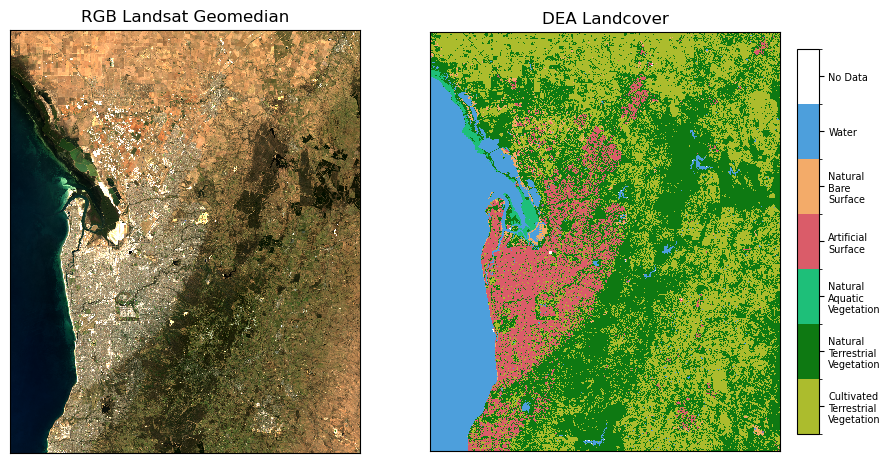

In [5]:
fig, ax = plt.subplots(1,2, figsize=(11,5.5), sharey=True)

ds[['nbart_red', 'nbart_green', 'nbart_blue']].to_array().plot.imshow(robust=True, ax=ax[0], add_labels=False)
ax[0].set_title("RGB Landsat Geomedian");
ax[0].axes.get_xaxis().set_ticks([])
ax[0].axes.get_yaxis().set_ticks([])

colour_scheme = get_colour_scheme('level3')
cmap, norm = lc_colourmap(colour_scheme)
im = lc.plot(cmap=cmap, norm=norm, ax=ax[1], add_labels=False, add_colorbar=False)
make_colourbar(fig, ax[1], measurement='level3', labelsize=7, horizontal=False)

ax[1].set_title("DEA Landcover");
ax[1].axes.get_xaxis().set_ticks([])
ax[1].axes.get_yaxis().set_ticks([]);

## Extract random samples from DEA-Landcover

Using the different sampling strategies outlined in the Description section above.

In [6]:
#Manual samples per class
print('User defined per-class samples')
train_points_manual = random_sampling_xr(
    lc,
    sampling="manual",
    manual_class_ratios={
        "111": 100,
        "112": 25,
        "124": 25,
        "215": 75,
        "216": 35,
        "220": 40,
    },
)
print('\n')
print('Stratified random samples')
#Stratified random samples 
train_points_stratified_random = random_sampling_xr(
    lc, sampling="stratified_random", n=400
)
print('\n')
print('Equal stratified random samples')
# Equal stratified random samples
train_points_equal_stratified_random = random_sampling_xr(
    lc, sampling="equal_stratified_random", n=400
)
print('\n')
print('Simple random samples')
#Simple random samples
train_points_random = random_sampling_xr(lc, sampling="random", n=400)

User defined per-class samples
Class 111: sampling 100 points
Class 112: sampling 25 points
Class 124: sampling 25 points
Class 215: sampling 75 points
Class 216: sampling 35 points
Class 220: sampling 40 points


Stratified random samples
Class 111: sampling 129 points
Class 112: sampling 163 points
Class 124: sampling 3 points
Class 215: sampling 39 points
Class 216: sampling 5 points
Class 220: sampling 61 points


Equal stratified random samples
Class 111: sampling 67 points
Class 112: sampling 67 points
Class 124: sampling 67 points
Class 215: sampling 67 points
Class 216: sampling 67 points
Class 220: sampling 67 points


Simple random samples
Sampling 400 points


### Plot the samples

Plotting the samples over the geomedian map will provide context for the sample locations

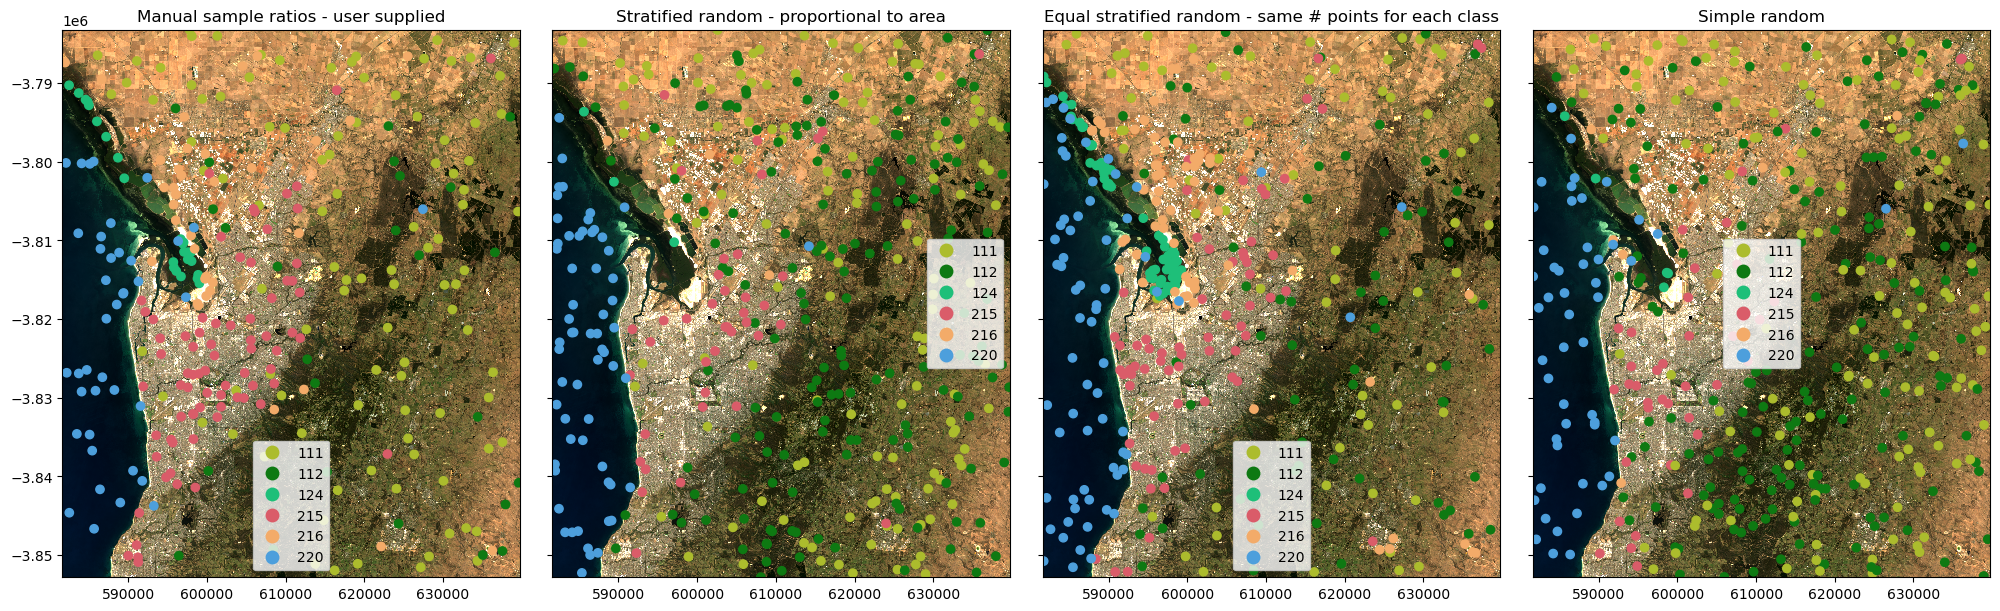

In [7]:
fig, ax = plt.subplots(1, 4, figsize=(20, 6), sharey=True, layout="constrained")

#trim no-data off the colormap
cmap=ListedColormap(cmap.colors[:-1])

ds[["nbart_red", "nbart_green", "nbart_blue"]].to_array().plot.imshow(
    robust=True, ax=ax[0], add_labels=False)
train_points_manual.plot(ax=ax[0], column="class", cmap=cmap, legend=True, categorical=True)
ax[0].set_title("Manual sample ratios - user supplied")

ds[["nbart_red", "nbart_green", "nbart_blue"]].to_array().plot.imshow(
    robust=True, ax=ax[1], add_labels=False)
train_points_stratified_random.plot(ax=ax[1], column="class", cmap=cmap, legend=True, categorical=True)
ax[1].set_title("Stratified random - proportional to area")

ds[["nbart_red", "nbart_green", "nbart_blue"]].to_array().plot.imshow(
    robust=True, ax=ax[2], add_labels=False)
train_points_equal_stratified_random.plot(ax=ax[2], column="class", cmap=cmap, legend=True, categorical=True)
ax[2].set_title("Equal stratified random - same # points for each class")

ds[["nbart_red", "nbart_green", "nbart_blue"]].to_array().plot.imshow(
    robust=True, ax=ax[3], add_labels=False)
train_points_random.plot(ax=ax[3], column="class", cmap=cmap, legend=True, categorical=True)
ax[3].set_title("Simple random");

## Sampling extremely large rasters

One of the key features of `random_sampling_xr` is its ability to extract samples form extremely large rasters while still efficiently managing memory.  

When a given class in a raster contains fewer than one billion samples (pixels), the function will create a mask of where all pixels match a given class, and then randomly sample the class using [numpy.random.choice](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html). However, when the number of samples exceeds one billion, to reduce memory usage, the function will instead randomly sample a subset of all pixel coordinates and check which ones match the target class. To reduce the chance of undersampling, the parameter `oversample_factor` controls how many candidate coordinates are initially drawn. For example, if 100 samples are required and `oversample_factor=5`, 500 random (x, y) coordinates will be sampled first. Only those matching the class will be retained and then randomly sub-sampled down to the desired number of samples. If too few valid matches are found, a warning is issued. Increasing the `oversample_factor` value can improve success rates when sampling sparse or spatially fragmented classes in large datasets, at the cost of more memory and computation.

In the example below, we load DEA Landcover over the Australian continent at 60 metre resolution, this results in ~**4 billion** float32 pixels (float because we mask the `255` no-data values). When extracting samples using the `equal_stratified_random` method, the function uses 30-40 GiB of RAM and takes about 5-6 mins to complete.

We include an example below as markdown text only because this example uses too much memory for a small machine like the DEA Sandbox, but if you have access to a larger machine you can test it out yourself.

### Sampling DEA Landcover over the entire Australian Continent

```
# Load DEA Land Cover over whole continent
lc = dc.load(
    product="ga_ls_landcover_class_cyear_3",
    output_crs="EPSG:3577",
    measurements=[
        "level3",
    ],
    resolution=(-60, 60),
    time=time
)

lc = lc['level3'].squeeze()
lc = lc.where(lc!=255)

print('total pixels =', len(lc.x)*len(lc.y))

# Extract random samples with large oversample factor
train_points_equal_stratified_random = random_sampling_xr(
    lc, sampling="equal_stratified_random", n=3000, oversample_factor=10
)

# Plot the samples
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

train_points_equal_stratified_random.plot(
    ax=ax,
    column="class",
    cmap=cmap,
    categorical=True,
    legend=True,
)

ax.set_title("Equal stratified random - same n-points for each class")
ax.axes.get_xaxis().set_ticks([])
ax.axes.get_yaxis().set_ticks([]);

```

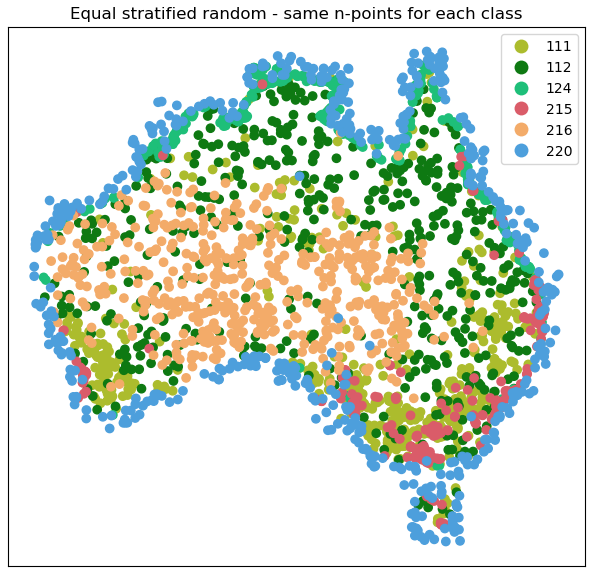

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** July 2025

**Compatible datacube version:** 

In [11]:
print(datacube.__version__)

1.8.19


## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->